# EJ-232 Scintillator: Photon Arrival Time Analysis

Diese Analyse verwendet die Geant4-Simulationsdaten eines EJ-232-Szintillators, auf den ein Elektron trifft. Die dabei erzeugten optischen Photonen werden an der oberen und unteren Fläche gezaehlt (Spalte `hit`), zusammen mit ihrer Ankunftszeit relativ zum Elektronentreffer (`timesinceelectronhit`).

**Spalten der CSV-Datei:**
- `runID`, `eventID`, `trackID` - Identifikatoren
- `hit` - getroffene Flaeche (`top` / `bottom`)
- `globaltime` - globale Simulationszeit
- `timesinceelectronhit` - Zeit seit dem Elektronentreffer (Photon-Ankunftszeit)
- `trackLength` - Weglaenge des Photons
- `photonEnergy`, `photonFlightTime`, `photonCreationTime` - Photon-Eigenschaften
- `creatorProcess` - erzeugender Prozess (z.B. `Scintillation`)

**Ziel dieser Analyse:**
1. Histogramm aller Photon-Ankunftszeiten (`timesinceelectronhit`) ueber alle Events und Fit mit dem szintillator-typischen Pulsmodell (ansteigende x abfallende Exponentialfunktion), um $\tau_{rise}$ und $\tau_{fall}$ zu bestimmen.
2. Denselben Fit pro einzelnem Event (gruppiert nach `eventID`) durchfuehren und die Verteilung der event-weisen Anstiegszeiten $\tau_{rise}$ plotten, um den Timing-Jitter des Szintillators abzuschaetzen.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

plt.rcParams["figure.dpi"] = 110

## 1. Daten einlesen

Die CSV-Datei beginnt mit `#`-Kommentarzeilen (Metadaten aus `tools::wcsv::ntuple`), erst danach folgen die eigentlichen Datenzeilen. Spaltennamen und effiziente `dtype`s werden manuell vergeben, da die Datei recht gross ist (>150 MB).

In [5]:
CSV_PATH = "data1.csv"

COLUMN_NAMES = [
    "runID", "eventID", "trackID", "hit", "globaltime",
    "timesinceelectronhit", "trackLength", "photonEnergy",
    "photonFlightTime", "photonCreationTime", "creatorProcess",
]

DTYPES = {
    "runID": "int32",
    "eventID": "int32",
    "trackID": "int32",
    "hit": "category",
    "globaltime": "float64",
    "timesinceelectronhit": "float64",
    "trackLength": "float32",
    "photonEnergy": "float32",
    "photonFlightTime": "float32",
    "photonCreationTime": "float32",
    "creatorProcess": "category",
}

df = pd.read_csv(CSV_PATH, comment="#", header=None, names=COLUMN_NAMES, dtype=DTYPES)

print(f"{len(df):,} Photon-Treffer geladen, {df['eventID'].nunique():,} Events")
df.head()

2,003,914 Photon-Treffer geladen, 1,000 Events


,runID,eventID,trackID,hit,globaltime,timesinceelectronhit,trackLength,photonEnergy,photonFlightTime,photonCreationTime,creatorProcess
0,0,0,5030,bottom,1.56980,1.242910,46.897800,3.52157,0.161860,1.081050,Scintillation
1,0,0,5027,top,1.09030,0.763410,39.697201,3.00475,0.140031,0.623380,Scintillation
2,0,0,5025,bottom,3.82479,3.497900,35.121601,3.00818,0.125301,3.372600,Scintillation
3,0,0,5024,bottom,1.10217,0.775282,50.239399,3.44397,0.186554,0.588728,Scintillation
4,0,0,5020,bottom,1.39016,1.063270,55.129902,3.23245,0.202117,0.861150,Scintillation


## 2. Pulsmodell: ansteigende x abfallende Exponentialfunktion

Fuer organische Szintillatoren (wie EJ-232) wird die zeitliche Emission der Szintillationsphotonen typischerweise durch die Faltung einer ansteigenden und einer abfallenden Exponentialfunktion beschrieben (dieselbe Form, die Geant4 intern fuer `G4Scintillation` verwendet):

$$ f(t) = A \left(1 - e^{-(t-t_0)/\tau_{rise}}\right)\, e^{-(t-t_0)/\tau_{fall}}, \qquad t \ge t_0 $$

mit $f(t) = 0$ fuer $t < t_0$. Dabei ist $\tau_{rise}$ die Anstiegszeit und $\tau_{fall}$ die Abklingzeit des Szintillators, $t_0$ die Startzeit des Pulses und $A$ eine Amplitude.

In [6]:
def pulse_shape(t, A, t0, tau_rise, tau_fall):
    """Szintillator-Pulsform: ansteigende x abfallende Exponentialfunktion."""
    t = np.asarray(t, dtype=float)
    dt = t - t0
    shape = np.zeros_like(dt)
    mask = dt > 0
    shape[mask] = (1.0 - np.exp(-dt[mask] / tau_rise)) * np.exp(-dt[mask] / tau_fall)
    return A * shape

## 3. Globaler Fit ueber alle Events

Zunaechst wird die Verteilung aller Photon-Ankunftszeiten (ueber alle Events und beide Flaechen) histogrammiert und mit dem obigen Modell gefittet, um globale Werte fuer $\tau_{rise}$ und $\tau_{fall}$ zu erhalten.

In [14]:
arrival_times = df["timesinceelectronhit"].to_numpy()

bin_width = 0.01  # ns (feinere Bins fuer bessere Aufloesung, z.B. der Cerenkov-Spitze)
bins = np.arange(arrival_times.min(), arrival_times.max() + bin_width, bin_width)
counts, edges = np.histogram(arrival_times, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

p0 = [counts.max(), centers[np.argmax(counts)] - 0.3, 0.3, 1.5]
bounds = ([0, arrival_times.min() - 1, 1e-3, 1e-3], [np.inf, arrival_times.max(), 50, 50])

popt, pcov = curve_fit(pulse_shape, centers, counts, p0=p0, bounds=bounds, maxfev=20000)
perr = np.sqrt(np.diag(pcov))
A_fit, t0_fit, tau_rise_fit, tau_fall_fit = popt

print(f"t0     = {t0_fit:.4f} ns")
print(f"t_rise = {tau_rise_fit:.4f} +/- {perr[2]:.4f} ns")
print(f"t_fall = {tau_fall_fit:.4f} +/- {perr[3]:.4f} ns")

t0     = 0.0885 ns
t_rise = 0.5250 +/- 0.0130 ns
t_fall = 1.5522 +/- 0.0123 ns


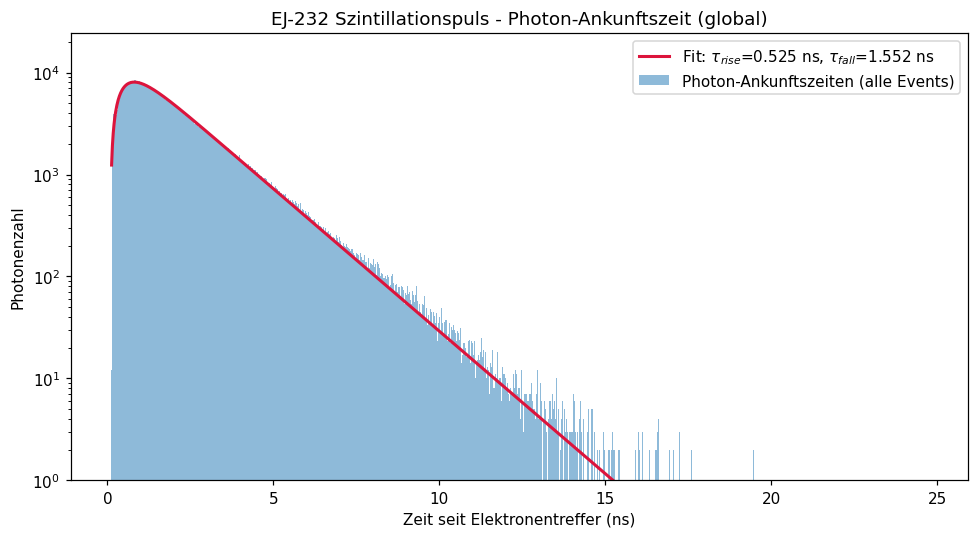

In [15]:
t_fine = np.linspace(centers.min(), centers.max(), 2000)

plt.figure(figsize=(9, 5))
plt.bar(centers, counts, width=bin_width, alpha=0.5, label="Photon-Ankunftszeiten (alle Events)")
plt.plot(t_fine, pulse_shape(t_fine, *popt), color="crimson", lw=2,
         label=fr"Fit: $\tau_{{rise}}$={tau_rise_fit:.3f} ns, $\tau_{{fall}}$={tau_fall_fit:.3f} ns")
plt.xlabel("Zeit seit Elektronentreffer (ns)")
plt.ylabel("Photonenzahl")
plt.yscale("log")
plt.ylim(bottom=1)
plt.title("EJ-232 Szintillationspuls - Photon-Ankunftszeit (global)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Fit pro einzelnem Event

Nun wird derselbe Fit fuer jedes einzelne Event separat durchgefuehrt (gruppiert nach `eventID`). Events mit zu wenigen Photonen werden uebersprungen, da fuer diese kein sinnvoller Fit moeglich ist. Anschliessend wird die Verteilung der event-weisen Anstiegszeiten $\tau_{rise}$ betrachtet - ihre Streuung entspricht dem Timing-Jitter des Szintillators.

In [9]:
def fit_single_event(times, bin_width=0.1, min_photons=15):
    """Fittet die Pulsform an die Ankunftszeiten eines einzelnen Events."""
    if len(times) < min_photons:
        return None

    tmin, tmax = times.min(), times.max()
    if tmax - tmin < 2 * bin_width:
        return None

    bins = np.arange(tmin, tmax + bin_width, bin_width)
    counts, edges = np.histogram(times, bins=bins)
    if counts.max() < 3:
        return None
    centers = 0.5 * (edges[:-1] + edges[1:])

    p0 = [counts.max(), centers[np.argmax(counts)] - 0.3, 0.3, 1.5]
    bounds = ([0, tmin - 1, 1e-3, 1e-3], [np.inf, tmax, 50, 50])

    try:
        popt, pcov = curve_fit(pulse_shape, centers, counts, p0=p0, bounds=bounds, maxfev=5000)
    except (RuntimeError, ValueError):
        return None

    if not np.all(np.isfinite(pcov)):
        return None

    A, t0, tau_rise, tau_fall = popt
    return {"A": A, "t0": t0, "tau_rise": tau_rise, "tau_fall": tau_fall, "n_photons": len(times)}

In [10]:
event_fits = []
for event_id, group in tqdm(df.groupby("eventID"), desc="Fitte Events"):
    fit = fit_single_event(group["timesinceelectronhit"].to_numpy())
    if fit is not None:
        fit["eventID"] = event_id
        event_fits.append(fit)

event_fits_df = pd.DataFrame(event_fits)
print(f"{len(event_fits_df):,} von {df['eventID'].nunique():,} Events erfolgreich gefittet")
event_fits_df.head()

Fitte Events:   0%|          | 0/1000 [00:00<?, ?it/s]

1,000 von 1,000 Events erfolgreich gefittet


,A,t0,tau_rise,tau_fall,n_photons,eventID
0,166.422211,0.028316,0.672309,1.451741,1663,0
1,151.512689,0.020618,0.724636,1.492025,1527,1
2,204.908841,-0.026962,0.854865,1.466498,1873,2
3,446.558337,0.107306,0.541617,1.540685,5126,3
4,167.173106,0.075815,0.467415,1.557555,1997,4


## 5. Timing-Jitter: Verteilung der event-weisen Anstiegszeiten

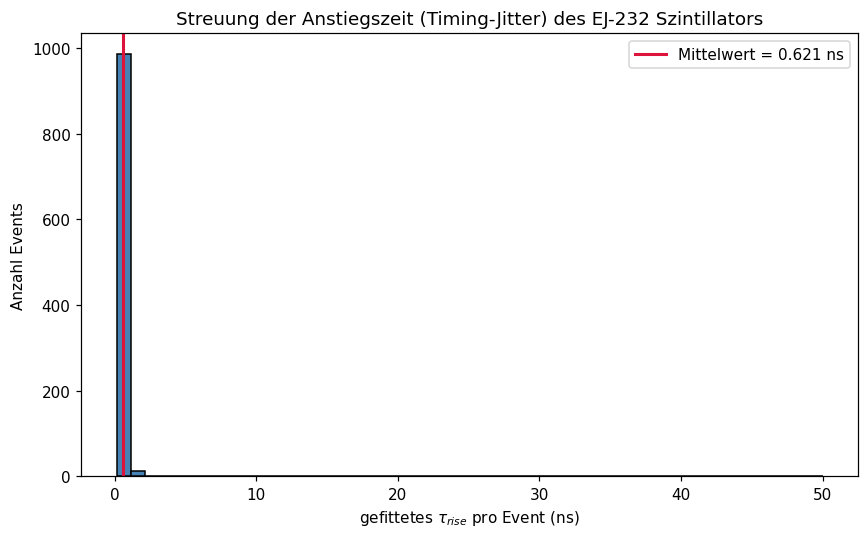

Mittleres tau_rise = 0.6205 ns
Jitter (Standardabweichung von tau_rise) = 1.5765 ns


In [11]:
mean_rise = event_fits_df["tau_rise"].mean()
std_rise = event_fits_df["tau_rise"].std()

plt.figure(figsize=(8, 5))
plt.hist(event_fits_df["tau_rise"], bins=50, color="steelblue", edgecolor="black")
plt.axvline(mean_rise, color="crimson", lw=2, label=f"Mittelwert = {mean_rise:.3f} ns")
plt.xlabel(r"gefittetes $\tau_{rise}$ pro Event (ns)")
plt.ylabel("Anzahl Events")
plt.title("Streuung der Anstiegszeit (Timing-Jitter) des EJ-232 Szintillators")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mittleres tau_rise = {mean_rise:.4f} ns")
print(f"Jitter (Standardabweichung von tau_rise) = {std_rise:.4f} ns")

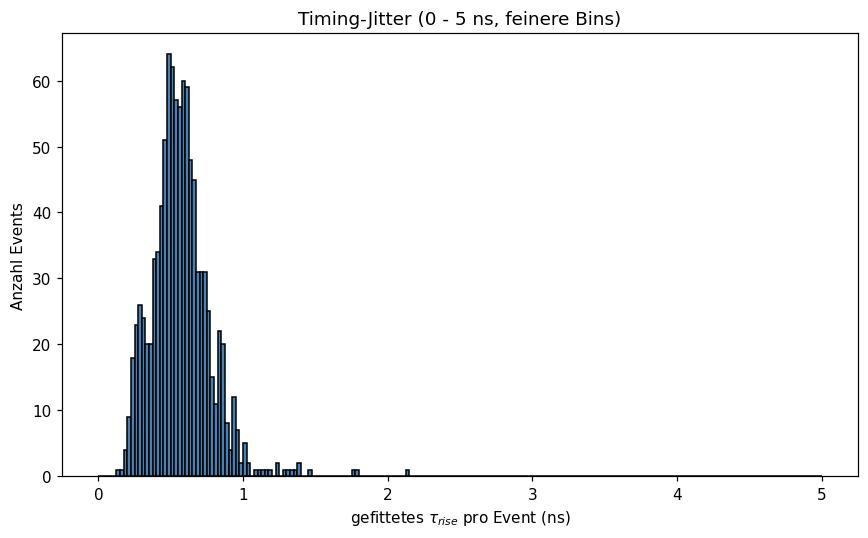

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(event_fits_df["tau_rise"], bins=200, range=(0, 5), color="steelblue", edgecolor="black")
plt.xlabel(r"gefittetes $\tau_{rise}$ pro Event (ns)")
plt.ylabel("Anzahl Events")
plt.title("Timing-Jitter (0 - 5 ns, feinere Bins)")
plt.tight_layout()
plt.show()

Normal    : AIC =   3751.3, Parameter = (0.6205, 1.5757)
Lognormal : AIC =   -293.0, Parameter = (0.3866, 0, 0.539)
Gamma     : AIC =    386.6, Parameter = (3.709, 0, 0.1673)


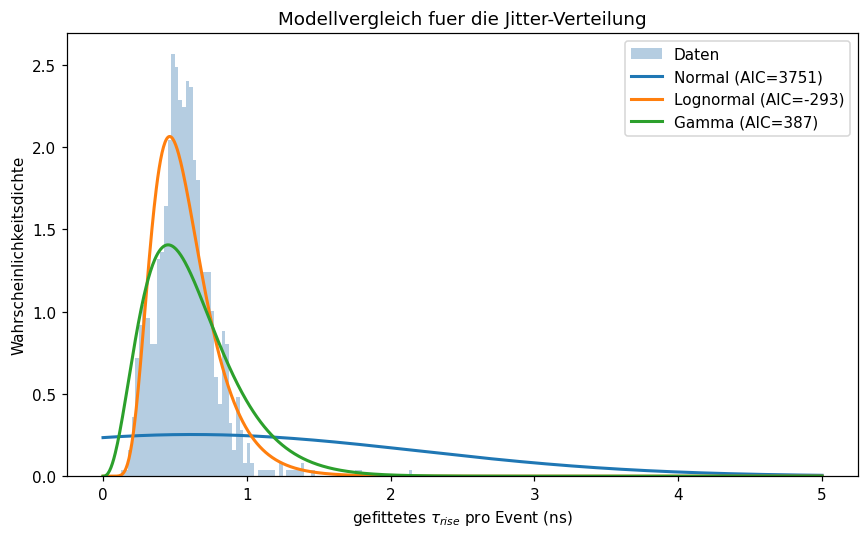

In [29]:
from scipy import stats

tau_rise_vals = event_fits_df["tau_rise"].to_numpy()

candidate_models = {
    "Normal": (stats.norm, {}),
    "Lognormal": (stats.lognorm, {"floc": 0}),  # loc=0 fest, da tau_rise > 0
    "Gamma": (stats.gamma, {"floc": 0}),
}

fit_results = {}
for name, (dist, fit_kwargs) in candidate_models.items():
    params = dist.fit(tau_rise_vals, **fit_kwargs)
    loglik = np.sum(dist.logpdf(tau_rise_vals, *params))
    aic = 2 * len(params) - 2 * loglik  # kleineres AIC = besserer Fit
    fit_results[name] = (params, aic)
    print(f"{name:10s}: AIC = {aic:8.1f}, Parameter = {tuple(round(p, 4) for p in params)}")

x = np.linspace(0.001, 5, 1000)
plt.figure(figsize=(8, 5))
plt.hist(tau_rise_vals, bins=200, range=(0, 5), density=True, color="steelblue", alpha=0.4, label="Daten")
for name, (params, aic) in fit_results.items():
    dist = candidate_models[name][0]
    plt.plot(x, dist.pdf(x, *params), lw=2, label=f"{name} (AIC={aic:.0f})")
plt.xlabel(r"gefittetes $\tau_{rise}$ pro Event (ns)")
plt.ylabel("Wahrscheinlichkeitsdichte")
plt.title("Modellvergleich fuer die Jitter-Verteilung")
plt.legend()
plt.tight_layout()
plt.show()

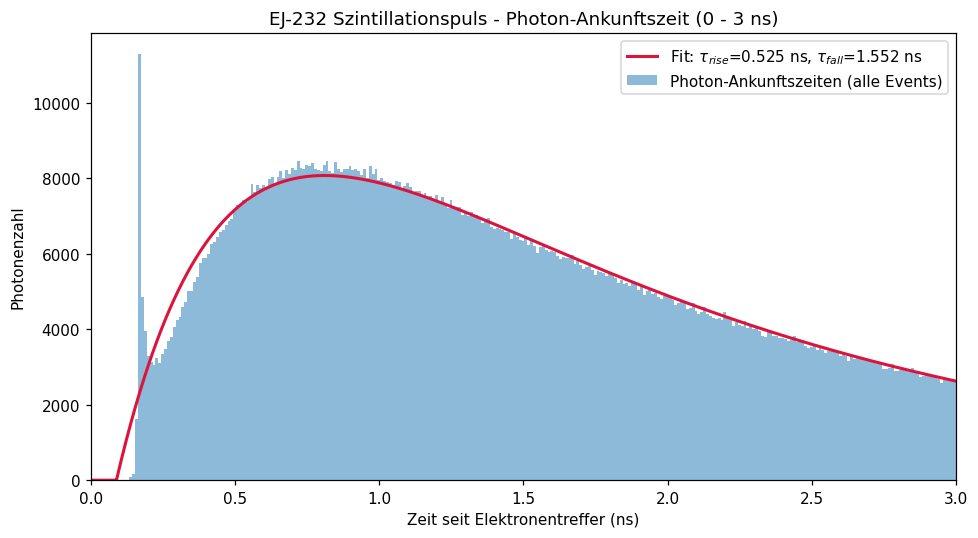

In [16]:
t_zoom_min, t_zoom_max = 0.0, 3.0
zoom_mask = (centers >= t_zoom_min) & (centers <= t_zoom_max)
t_fine_zoom = np.linspace(t_zoom_min, t_zoom_max, 2000)

plt.figure(figsize=(9, 5))
plt.bar(centers[zoom_mask], counts[zoom_mask], width=bin_width, alpha=0.5,
        label="Photon-Ankunftszeiten (alle Events)")
plt.plot(t_fine_zoom, pulse_shape(t_fine_zoom, *popt), color="crimson", lw=2,
         label=fr"Fit: $\tau_{{rise}}$={tau_rise_fit:.3f} ns, $\tau_{{fall}}$={tau_fall_fit:.3f} ns")
plt.xlabel("Zeit seit Elektronentreffer (ns)")
plt.ylabel("Photonenzahl")
plt.xlim(t_zoom_min, t_zoom_max)
plt.title("EJ-232 Szintillationspuls - Photon-Ankunftszeit (0 - 3 ns)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Cerenkov- vs. Szintillationsphotonen

In der Zoom-Ansicht (0 - 3 ns) faellt ein scharfer Peak bei $t \approx 0.15-0.2$ ns auf, deutlich *vor* dem Anstieg des Szintillationspulses. Das ist Cerenkov-Licht: es entsteht praktisch instantan beim Durchflug des Elektrons (keine Anstiegs-/Abklingzeit), die kleine Verzoegerung kommt nur von der Flugzeit der Photonen bis zur Flaeche. Die Spalte `creatorProcess` erlaubt es, dies direkt zu bestaetigen.

In [ ]:
df["creatorProcess"].value_counts()


creatorProcess
Scintillation    1965783
Cerenkov           38131
Name: count, dtype: int64

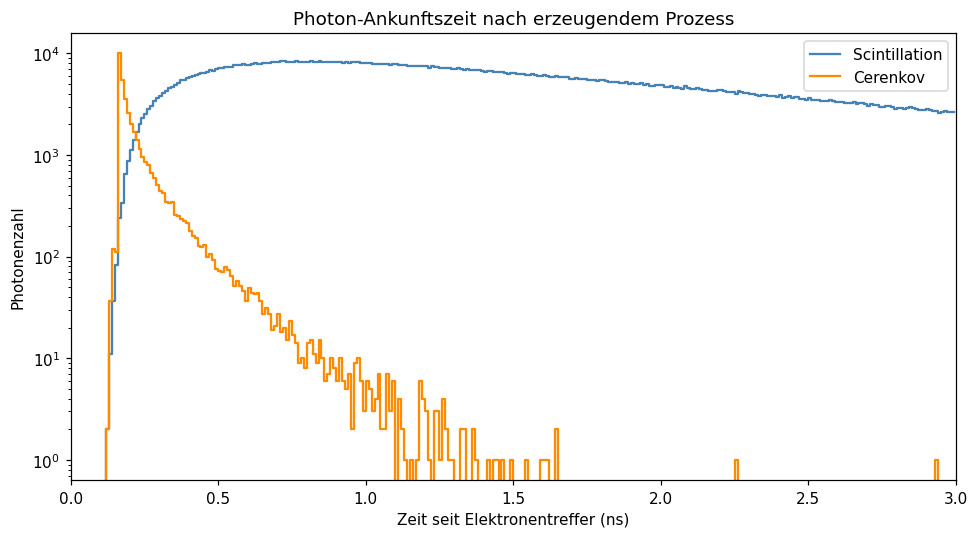

In [17]:
bin_width_zoom = 0.01  # ns
bins_zoom = np.arange(0, 3 + bin_width_zoom, bin_width_zoom)
centers_zoom = 0.5 * (bins_zoom[:-1] + bins_zoom[1:])

plt.figure(figsize=(9, 5))
for process, color in [("Scintillation", "steelblue"), ("Cerenkov", "darkorange")]:
    times_p = df.loc[df["creatorProcess"] == process, "timesinceelectronhit"].to_numpy()
    counts_p, _ = np.histogram(times_p, bins=bins_zoom)
    plt.step(centers_zoom, counts_p, where="mid", color=color, label=process)

plt.xlabel("Zeit seit Elektronentreffer (ns)")
plt.ylabel("Photonenzahl")
plt.yscale("log")
plt.xlim(0, 3)
plt.title("Photon-Ankunftszeit nach erzeugendem Prozess")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Anstiegs- und Abklingzeit des Cerenkov-Lichts

Derselbe Fit wie in Abschnitt 3 wird nun nur auf die Cerenkov-Photonen angewendet. Da der Cerenkov-Peak sehr schmal und prompt ist, werden deutlich feinere Bins verwendet.

t0     = 0.1612 ns
t_rise = 0.0002 +/- 0.0020 ns
t_fall = 0.0154 +/- 0.0004 ns


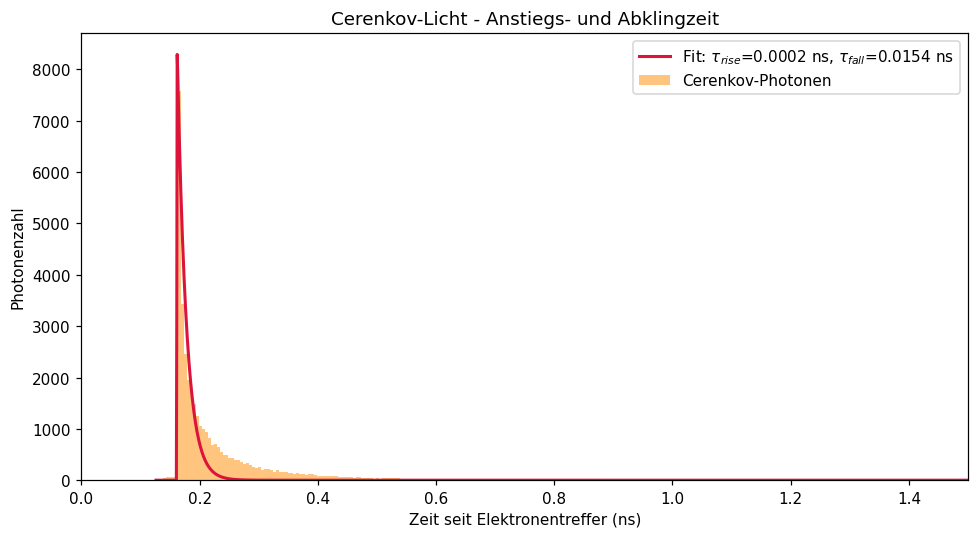

In [18]:
cerenkov_times = df.loc[df["creatorProcess"] == "Cerenkov", "timesinceelectronhit"].to_numpy()

bin_width_cer = 0.005  # ns, sehr fein wegen des schmalen, prompten Cerenkov-Peaks
bins_cer = np.arange(cerenkov_times.min(), cerenkov_times.max() + bin_width_cer, bin_width_cer)
counts_cer, edges_cer = np.histogram(cerenkov_times, bins=bins_cer)
centers_cer = 0.5 * (edges_cer[:-1] + edges_cer[1:])

p0_cer = [counts_cer.max(), centers_cer[np.argmax(counts_cer)] - 0.05, 0.02, 0.1]
bounds_cer = ([0, cerenkov_times.min() - 0.5, 1e-4, 1e-4], [np.inf, cerenkov_times.max(), 5, 5])

popt_cer, pcov_cer = curve_fit(pulse_shape, centers_cer, counts_cer, p0=p0_cer, bounds=bounds_cer, maxfev=20000)
perr_cer = np.sqrt(np.diag(pcov_cer))
A_cer, t0_cer, tau_rise_cer, tau_fall_cer = popt_cer

print(f"t0     = {t0_cer:.4f} ns")
print(f"t_rise = {tau_rise_cer:.4f} +/- {perr_cer[2]:.4f} ns")
print(f"t_fall = {tau_fall_cer:.4f} +/- {perr_cer[3]:.4f} ns")

t_fine_cer = np.linspace(centers_cer.min(), min(centers_cer.max(), 1.5), 2000)

plt.figure(figsize=(9, 5))
plt.bar(centers_cer, counts_cer, width=bin_width_cer, alpha=0.5, color="darkorange", label="Cerenkov-Photonen")
plt.plot(t_fine_cer, pulse_shape(t_fine_cer, *popt_cer), color="crimson", lw=2,
         label=fr"Fit: $\tau_{{rise}}$={tau_rise_cer:.4f} ns, $\tau_{{fall}}$={tau_fall_cer:.4f} ns")
plt.xlabel("Zeit seit Elektronentreffer (ns)")
plt.ylabel("Photonenzahl")
plt.xlim(0, 1.5)
plt.title("Cerenkov-Licht - Anstiegs- und Abklingzeit")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Photon-Energiespektrum

Ein reales PMT kann Licht nur in einem bestimmten Wellenlaengen- bzw. Energiebereich effizient nachweisen (Quanteneffizienz-Kurve). Deshalb lohnt sich ein Blick auf das Energiespektrum der erzeugten Photonen - zunaechst fuer den gesamten Prozess (Scintillation + Cerenkov), danach getrennt nach `creatorProcess`.

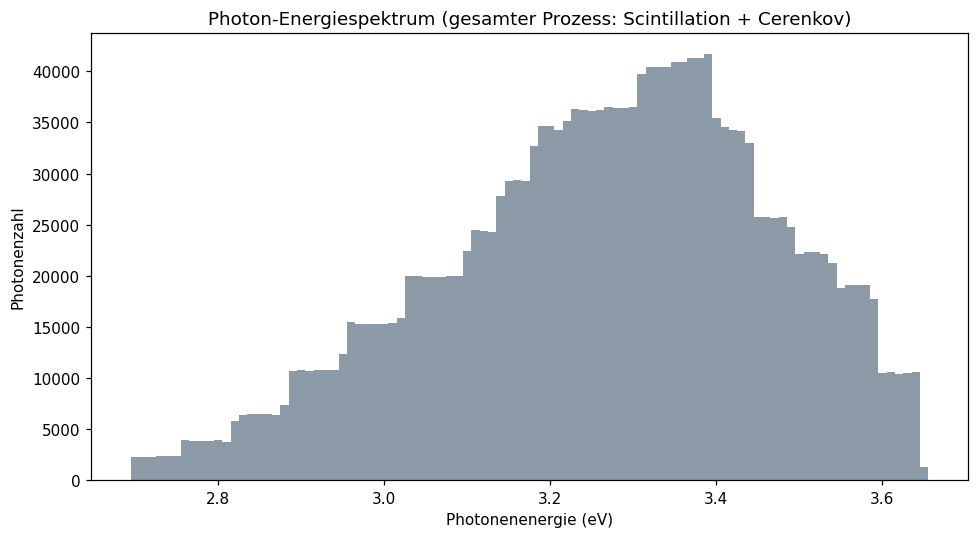

In [19]:
energy_bin_width = 0.01  # eV
energy_bins = np.arange(df["photonEnergy"].min(), df["photonEnergy"].max() + energy_bin_width, energy_bin_width)

plt.figure(figsize=(9, 5))
plt.hist(df["photonEnergy"], bins=energy_bins, color="slategray", alpha=0.8)
plt.xlabel("Photonenenergie (eV)")
plt.ylabel("Photonenzahl")
plt.title("Photon-Energiespektrum (gesamter Prozess: Scintillation + Cerenkov)")
plt.tight_layout()
plt.show()

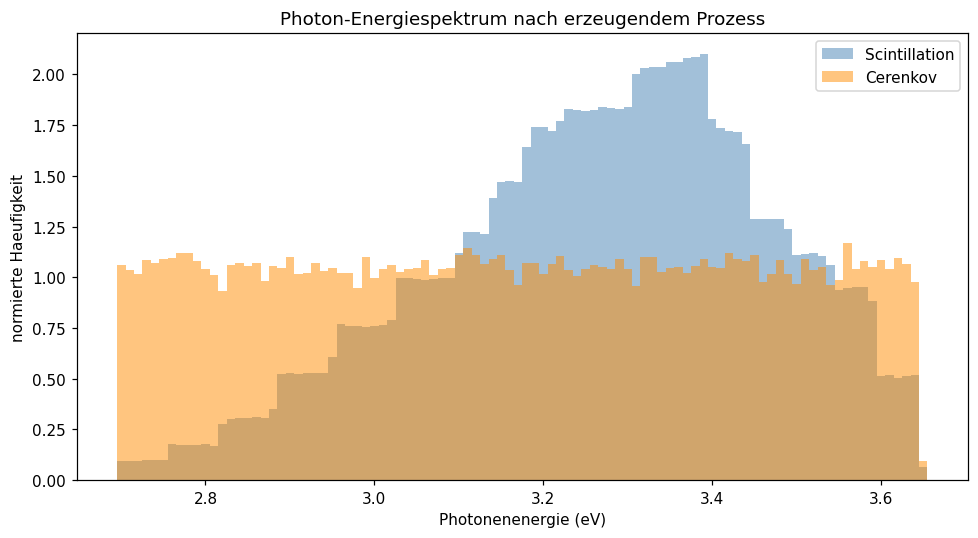

In [20]:
plt.figure(figsize=(9, 5))
for process, color in [("Scintillation", "steelblue"), ("Cerenkov", "darkorange")]:
    energies_p = df.loc[df["creatorProcess"] == process, "photonEnergy"].to_numpy()
    plt.hist(energies_p, bins=energy_bins, color=color, alpha=0.5, label=process, density=True)

plt.xlabel("Photonenenergie (eV)")
plt.ylabel("normierte Haeufigkeit")
plt.title("Photon-Energiespektrum nach erzeugendem Prozess")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Spektrum in Wellenlaenge

Dieselben Spektren wie in Abschnitt 8, aber mit der Wellenlaenge (nm) statt der Energie (eV) auf der x-Achse. Umrechnung ueber $\lambda = hc/E$.

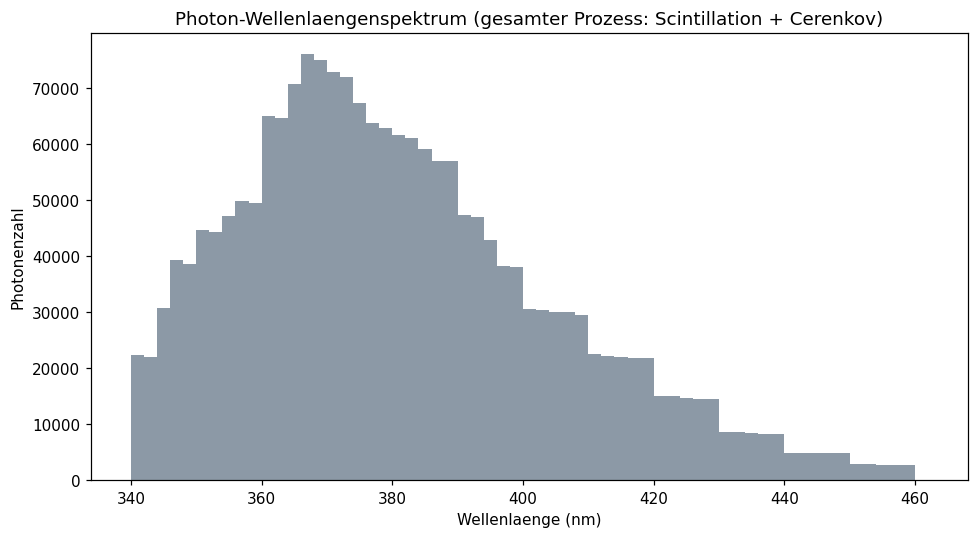

In [21]:
HC_EV_NM = 1239.84193  # eV * nm
df["photonWavelength"] = HC_EV_NM / df["photonEnergy"]

wavelength_bin_width = 2  # nm
wavelength_bins = np.arange(df["photonWavelength"].min(), df["photonWavelength"].max() + wavelength_bin_width, wavelength_bin_width)

plt.figure(figsize=(9, 5))
plt.hist(df["photonWavelength"], bins=wavelength_bins, color="slategray", alpha=0.8)
plt.xlabel("Wellenlaenge (nm)")
plt.ylabel("Photonenzahl")
plt.title("Photon-Wellenlaengenspektrum (gesamter Prozess: Scintillation + Cerenkov)")
plt.tight_layout()
plt.show()

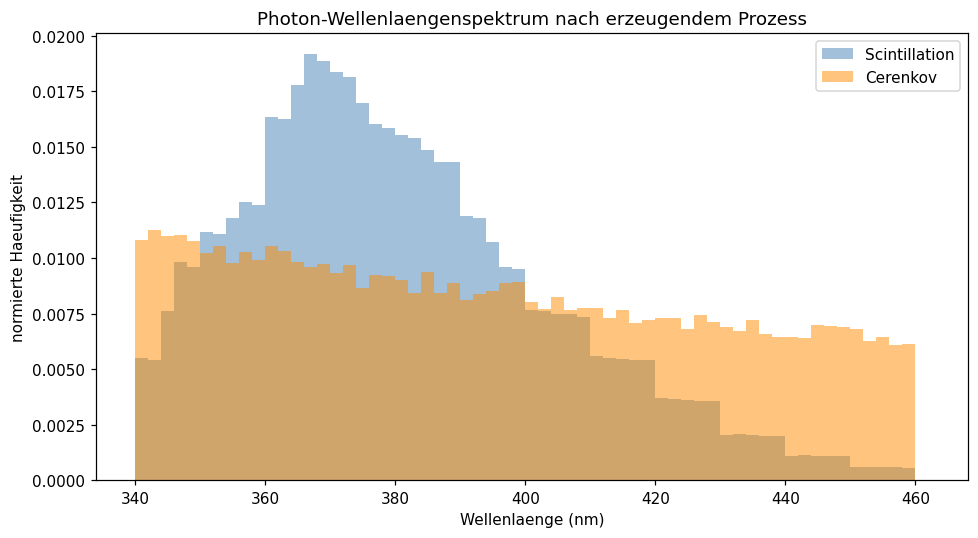

In [22]:
plt.figure(figsize=(9, 5))
for process, color in [("Scintillation", "steelblue"), ("Cerenkov", "darkorange")]:
    wavelengths_p = df.loc[df["creatorProcess"] == process, "photonWavelength"].to_numpy()
    plt.hist(wavelengths_p, bins=wavelength_bins, color=color, alpha=0.5, label=process, density=True)

plt.xlabel("Wellenlaenge (nm)")
plt.ylabel("normierte Haeufigkeit")
plt.title("Photon-Wellenlaengenspektrum nach erzeugendem Prozess")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Spektren mit absoluten Counts (Scintillation vs. Cerenkov)

Dieselben Vergleiche wie oben, aber mit absoluten Photonenzahlen statt normierter Haeufigkeit (log-Skala, da Scintillation ~50x haeufiger ist als Cerenkov).

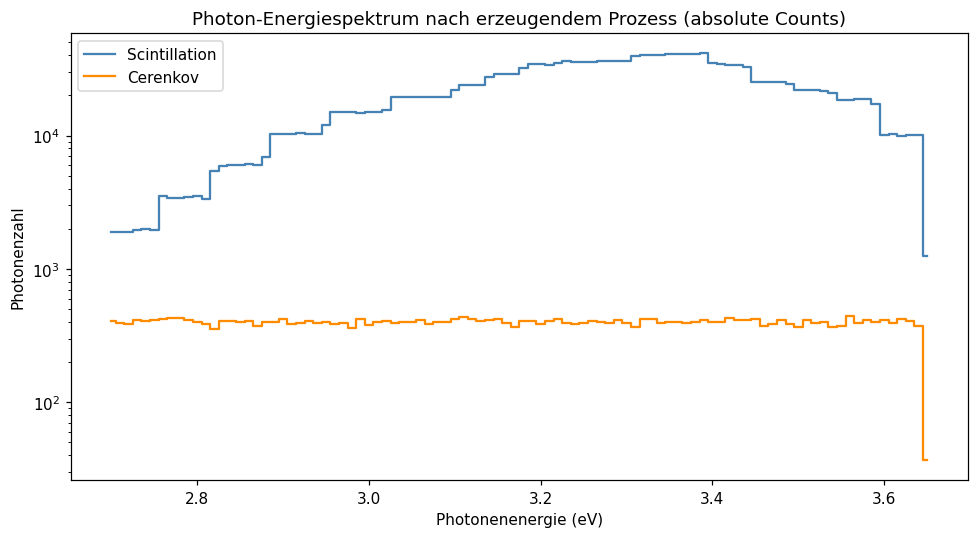

In [23]:
plt.figure(figsize=(9, 5))
for process, color in [("Scintillation", "steelblue"), ("Cerenkov", "darkorange")]:
    energies_p = df.loc[df["creatorProcess"] == process, "photonEnergy"].to_numpy()
    counts_e, edges_e = np.histogram(energies_p, bins=energy_bins)
    centers_e = 0.5 * (edges_e[:-1] + edges_e[1:])
    plt.step(centers_e, counts_e, where="mid", color=color, label=process)

plt.xlabel("Photonenenergie (eV)")
plt.ylabel("Photonenzahl")
plt.yscale("log")
plt.title("Photon-Energiespektrum nach erzeugendem Prozess (absolute Counts)")
plt.legend()
plt.tight_layout()
plt.show()

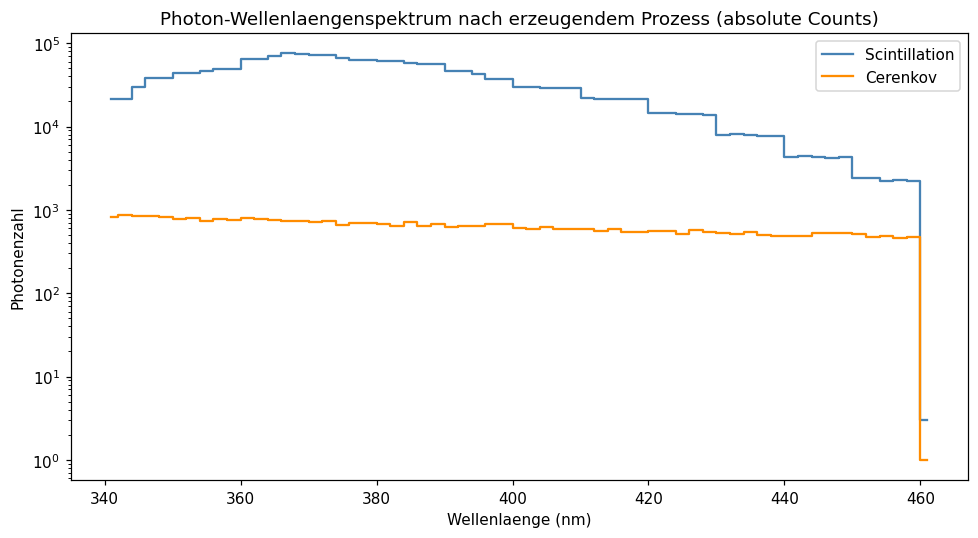

In [24]:
plt.figure(figsize=(9, 5))
for process, color in [("Scintillation", "steelblue"), ("Cerenkov", "darkorange")]:
    wavelengths_p = df.loc[df["creatorProcess"] == process, "photonWavelength"].to_numpy()
    counts_w, edges_w = np.histogram(wavelengths_p, bins=wavelength_bins)
    centers_w = 0.5 * (edges_w[:-1] + edges_w[1:])
    plt.step(centers_w, counts_w, where="mid", color=color, label=process)

plt.xlabel("Wellenlaenge (nm)")
plt.ylabel("Photonenzahl")
plt.yscale("log")
plt.title("Photon-Wellenlaengenspektrum nach erzeugendem Prozess (absolute Counts)")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
for process in ["Scintillation", "Cerenkov"]:
    e = df.loc[df["creatorProcess"] == process, "photonEnergy"]
    w = df.loc[df["creatorProcess"] == process, "photonWavelength"]
    print(f"{process}: Energie [{e.min():.4f}, {e.max():.4f}] eV -> Wellenlaenge [{w.min():.2f}, {w.max():.2f}] nm")

Scintillation: Energie [2.6953, 3.6466] eV -> Wellenlaenge [340.00, 460.00] nm
Cerenkov: Energie [2.6953, 3.6466] eV -> Wellenlaenge [340.00, 460.00] nm


## 11. Warum ist das Cerenkov-Spektrum so gleichmaessig verteilt?

Die Frank-Tamm-Formel sagt voraus, dass die Anzahl der Cerenkov-Photonen **pro Energieintervall** naeherungsweise konstant ist (solange der Brechungsindex $n$ und $\beta$ ueber den betrachteten Bereich kaum variieren):

$$ \frac{d^2N}{dx\,dE} = \frac{\alpha z^2}{\hbar c}\left(1 - \frac{1}{\beta^2 n^2(E)}\right) \approx \text{const.} $$

Erst die Umrechnung auf Wellenlaenge ($\lambda = hc/E$, $d\lambda = -hc/E^2\,dE$) erzeugt die bekannte $1/\lambda^2$-Kurve:

$$ \frac{d^2N}{dx\,d\lambda} \propto \frac{1}{\lambda^2} $$

Gruende, warum es in unseren Plots so flach aussieht:
1. **Flach in Energie ist die "natuerliche" Form** von Cerenkov-Licht (anders als Scintillation, die einen echten molekularen Emissionspeak hat).
2. **Schwache Dispersion**: Wenn der Brechungsindex im Material-Property-Table kaum von der Energie abhaengt, bleibt der $(1-1/(\beta^2 n^2))$-Faktor nahezu konstant.
3. **$\beta \approx 1$**: Die Elektronen sind schnell genug, sodass die Cerenkov-Schwelle im gesamten Tabellenbereich klar ueberschritten ist - kein energieabhaengiger Schwelleneffekt.
4. **Schmales Fenster**: Der $1/\lambda^2$-Effekt ist nur ueber einen sehr breiten Wellenlaengenbereich stark sichtbar. Da hier nur 340-460 nm zur Verfuegung stehen (siehe Abschnitt zuvor), faellt die Kruemmung kaum auf.

Energie-Domain:       max/min Bin-Verhaeltnis = 12.05
Wellenlaengen-Domain: max/min Bin-Verhaeltnis = 859.00


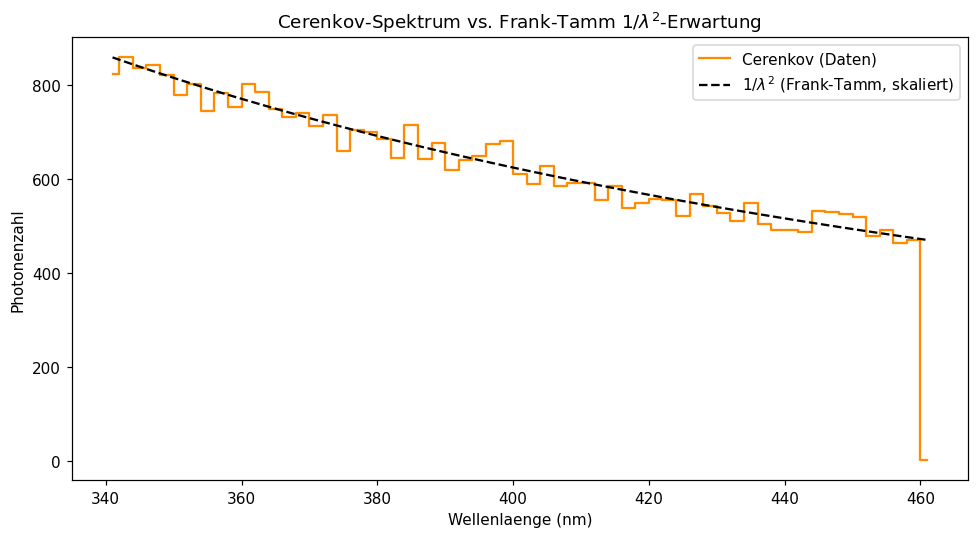

In [26]:
cerenkov_energy = df.loc[df["creatorProcess"] == "Cerenkov", "photonEnergy"].to_numpy()
cerenkov_wavelength = df.loc[df["creatorProcess"] == "Cerenkov", "photonWavelength"].to_numpy()

counts_cer_e, edges_cer_e = np.histogram(cerenkov_energy, bins=energy_bins)
counts_cer_w, edges_cer_w = np.histogram(cerenkov_wavelength, bins=wavelength_bins)

nonzero_e = counts_cer_e[counts_cer_e > 0]
nonzero_w = counts_cer_w[counts_cer_w > 0]

print(f"Energie-Domain:       max/min Bin-Verhaeltnis = {nonzero_e.max() / nonzero_e.min():.2f}")
print(f"Wellenlaengen-Domain: max/min Bin-Verhaeltnis = {nonzero_w.max() / nonzero_w.min():.2f}")

centers_cer_w = 0.5 * (edges_cer_w[:-1] + edges_cer_w[1:])
model = 1.0 / centers_cer_w**2  # Frank-Tamm: dN/dlambda ~ 1/lambda^2 bei ~konstantem n, beta
model_scaled = model * (counts_cer_w.max() / model.max())

plt.figure(figsize=(9, 5))
plt.step(centers_cer_w, counts_cer_w, where="mid", color="darkorange", label="Cerenkov (Daten)")
plt.plot(centers_cer_w, model_scaled, color="black", ls="--", label=r"$1/\lambda^2$ (Frank-Tamm, skaliert)")
plt.xlabel("Wellenlaenge (nm)")
plt.ylabel("Photonenzahl")
plt.title("Cerenkov-Spektrum vs. Frank-Tamm $1/\\lambda^2$-Erwartung")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Photon-Ankunftszeit getrennt nach Trefferflaeche (top vs. bottom)

Die Spalte `hit` gibt an, ob ein Photon die obere oder untere Flaeche des Szintillators erreicht hat. Hier wird der Pulsform-Fit (wie in Abschnitt 3) getrennt fuer beide Flaechen durchgefuehrt, um zu pruefen, ob sich Timing oder Photonenzahl zwischen den Seiten unterscheiden (z.B. durch Selbstabsorption oder Geometrie).

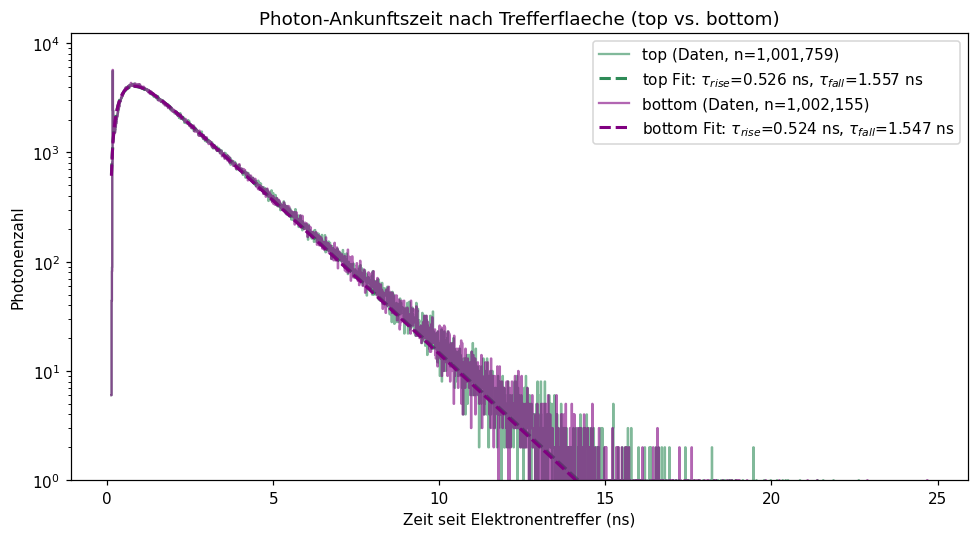

top: t0=0.0877 ns, tau_rise=0.5258 ns, tau_fall=1.5570 ns
bottom: t0=0.0892 ns, tau_rise=0.5242 ns, tau_fall=1.5473 ns


In [30]:
hit_fits = {}
plt.figure(figsize=(9, 5))
for hit_value, color in [("top", "seagreen"), ("bottom", "purple")]:
    times_hit = df.loc[df["hit"] == hit_value, "timesinceelectronhit"].to_numpy()
    counts_hit, edges_hit = np.histogram(times_hit, bins=bins)
    centers_hit = 0.5 * (edges_hit[:-1] + edges_hit[1:])

    p0_hit = [counts_hit.max(), centers_hit[np.argmax(counts_hit)] - 0.3, 0.3, 1.5]
    bounds_hit = ([0, times_hit.min() - 1, 1e-3, 1e-3], [np.inf, times_hit.max(), 50, 50])
    popt_hit, pcov_hit = curve_fit(pulse_shape, centers_hit, counts_hit, p0=p0_hit, bounds=bounds_hit, maxfev=20000)
    hit_fits[hit_value] = popt_hit

    plt.step(centers_hit, counts_hit, where="mid", color=color, alpha=0.6, label=f"{hit_value} (Daten, n={len(times_hit):,})")
    plt.plot(t_fine, pulse_shape(t_fine, *popt_hit), color=color, lw=2, ls="--",
              label=fr"{hit_value} Fit: $\tau_{{rise}}$={popt_hit[2]:.3f} ns, $\tau_{{fall}}$={popt_hit[3]:.3f} ns")

plt.xlabel("Zeit seit Elektronentreffer (ns)")
plt.ylabel("Photonenzahl")
plt.yscale("log")
plt.ylim(bottom=1)
plt.title("Photon-Ankunftszeit nach Trefferflaeche (top vs. bottom)")
plt.legend()
plt.tight_layout()
plt.show()

for hit_value, popt_hit in hit_fits.items():
    print(f"{hit_value}: t0={popt_hit[1]:.4f} ns, tau_rise={popt_hit[2]:.4f} ns, tau_fall={popt_hit[3]:.4f} ns")

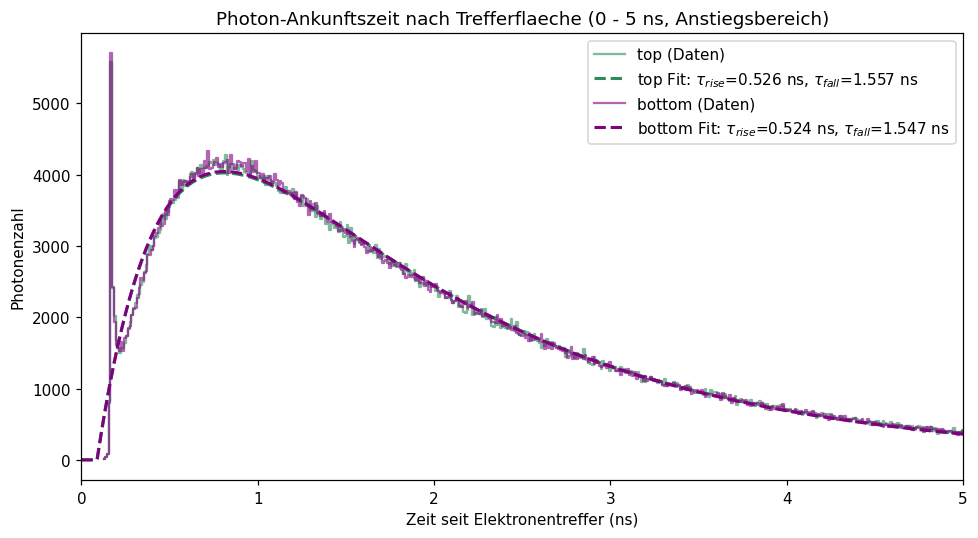

In [32]:
t_fine_zoom5 = np.linspace(0, 5, 2000)

plt.figure(figsize=(9, 5))
for hit_value, color in [("top", "seagreen"), ("bottom", "purple")]:
    times_hit = df.loc[df["hit"] == hit_value, "timesinceelectronhit"].to_numpy()
    counts_hit, edges_hit = np.histogram(times_hit, bins=bins)
    centers_hit = 0.5 * (edges_hit[:-1] + edges_hit[1:])
    zoom_mask_hit = (centers_hit >= 0) & (centers_hit <= 5)

    plt.step(centers_hit[zoom_mask_hit], counts_hit[zoom_mask_hit], where="mid", color=color, alpha=0.6,
              label=f"{hit_value} (Daten)")
    plt.plot(t_fine_zoom5, pulse_shape(t_fine_zoom5, *hit_fits[hit_value]), color=color, lw=2, ls="--",
              label=fr"{hit_value} Fit: $\tau_{{rise}}$={hit_fits[hit_value][2]:.3f} ns, $\tau_{{fall}}$={hit_fits[hit_value][3]:.3f} ns")

plt.xlabel("Zeit seit Elektronentreffer (ns)")
plt.ylabel("Photonenzahl")
plt.xlim(0, 5)
plt.title("Photon-Ankunftszeit nach Trefferflaeche (0 - 5 ns, Anstiegsbereich)")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Erzeugungszeit vs. Flugzeit (photonCreationTime vs. photonFlightTime)

`photonCreationTime` gibt an, wann ein Photon relativ zum Elektronentreffer entstanden ist, `photonFlightTime` wie lange es danach bis zur Trefferflaeche unterwegs war (`timesinceelectronhit` ≈ `photonCreationTime` + `photonFlightTime`). Fuer Cerenkov-Licht wird eine sehr scharfe, prompte `photonCreationTime` erwartet (Emission waehrend des Elektronendurchflugs, der nur wenige Pikosekunden dauert), waehrend die `photonFlightTime` durch unterschiedliche Entstehungsorte/Reflexionswege breiter gestreut sein sollte. Fuer Scintillation-Licht sollte es umgekehrt sein: `photonCreationTime` zeigt die volle Anstiegs-/Abklingform, `photonFlightTime` ist vergleichsweise schmal.

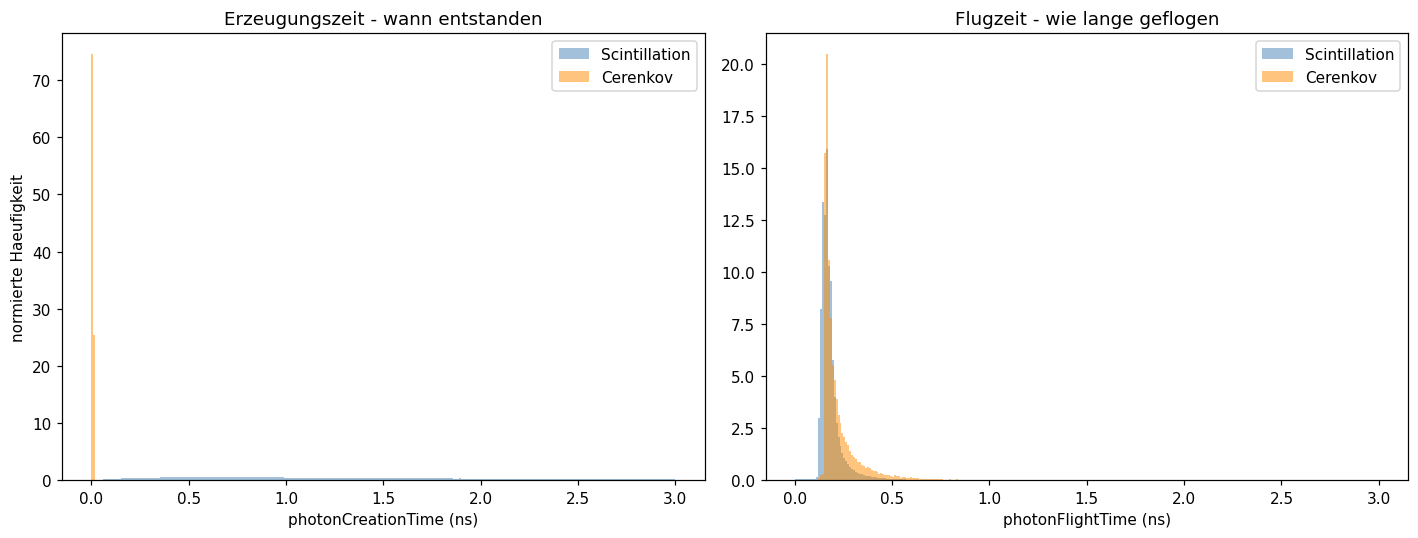

Scintillation: CreationTime mean=1.9203 std=1.6539 ns | FlightTime mean=0.1843 std=0.0712 ns
Cerenkov     : CreationTime mean=0.0067 std=0.0039 ns | FlightTime mean=0.2258 std=0.1164 ns


In [34]:
bin_width_ct = 0.01  # ns
bins_ct = np.arange(0, 3 + bin_width_ct, bin_width_ct)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for process, color in [("Scintillation", "steelblue"), ("Cerenkov", "darkorange")]:
    mask = df["creatorProcess"] == process
    creation_p = df.loc[mask, "photonCreationTime"].to_numpy()
    flight_p = df.loc[mask, "photonFlightTime"].to_numpy()

    axes[0].hist(creation_p, bins=bins_ct, color=color, alpha=0.5, label=process, density=True)
    axes[1].hist(flight_p, bins=bins_ct, color=color, alpha=0.5, label=process, density=True)

axes[0].set_xlabel("photonCreationTime (ns)")
axes[0].set_ylabel("normierte Haeufigkeit")
axes[0].set_title("Erzeugungszeit - wann entstanden")
axes[0].legend()

axes[1].set_xlabel("photonFlightTime (ns)")
axes[1].set_title("Flugzeit - wie lange geflogen")
axes[1].legend()

plt.tight_layout()
plt.show()

for process in ["Scintillation", "Cerenkov"]:
    mask = df["creatorProcess"] == process
    ct = df.loc[mask, "photonCreationTime"]
    ft = df.loc[mask, "photonFlightTime"]
    print(f"{process:13s}: CreationTime mean={ct.mean():.4f} std={ct.std():.4f} ns | "
          f"FlightTime mean={ft.mean():.4f} std={ft.std():.4f} ns")

**Ergebnis:** Cerenkov-`photonCreationTime` ist extrem scharf (Std = 0.0039 ns, praktisch punktfoermig - der Elektronendurchflug durch die 2mm dicke Szintillatorschicht dauert nur wenige Pikosekunden), waehrend die `photonFlightTime` deutlich breiter ist (Std = 0.1164 ns, ~30x breiter). Scintillation zeigt das erwartete Gegenteil: `photonCreationTime` hat die volle Pulsbreite (Std = 1.65 ns, entspricht $\tau_{rise}/\tau_{fall}$), waehrend die `photonFlightTime` mit Std = 0.0712 ns relativ eng bleibt. Das bestaetigt: die Breite des Cerenkov-Peaks in `timesinceelectronhit` (Abschnitt 7) kommt fast ausschliesslich von der Photon-Flugzeit, nicht von der Emissionszeit selbst.

## 14. Cerenkov-Schwelle: Machbarkeit einer Energieabhaengigkeits-Analyse

Eine Schwellenanalyse ($\beta_{min}=1/n$) braucht mehrere Elektronenenergien, um zu sehen, ab welcher Energie die Cerenkov-Photonenzahl auf 0 faellt. Dazu zunaechst ein Check, ob der Datensatz mehrere Runs/Energien enthaelt:

In [33]:
print(f"Anzahl runIDs: {df['runID'].nunique()}, Werte: {sorted(df['runID'].unique())[:10]}")
print(df.groupby("runID")["trackLength"].describe())

Anzahl runIDs: 1, Werte: [0]
           count       mean        std       min        25%        50%  \
runID                                                                    
0      2003914.0  51.485542  22.534351  0.000865  39.474899  45.702351   

             75%         max  
runID                         
0      54.848176  875.346008  


**Ergebnis:** Der Datensatz enthaelt nur `runID = 0`, also nur eine einzige Elektronenenergie/Simulationskonfiguration. `trackLength` beschreibt zudem die Weglaenge der *Photonen* (inkl. interner Reflexionen, daher Werte bis 875 - viel groesser als die 2mm Szintillatordicke), nicht die Position/Energie des Elektrons entlang seiner Bahn. Es gibt also **keine Spalte, aus der sich unterschiedliche Elektronenenergien oder eine variierende Geschwindigkeit $\beta$ ableiten liessen**.

Eine echte Schwellenanalyse ($\beta_{min}=1/n \approx 0{,}63$ fuer $n=1{,}58$) ist mit diesem einzelnen Datensatz daher **nicht direkt moeglich**. Um sie durchzufuehren, muesste die Simulation mit mehreren Elektronenenergien (bzw. mehreren `runID`s, jeweils mit bekannter Anfangsenergie) wiederholt werden; dann liesse sich die Cerenkov-Photonenzahl pro Event gegen die Energie auftragen und der erwartete abrupte Abfall unterhalb der Schwellenenergie sichtbar machen.


## 15. Photonenzahl pro Event vs. Elektronen-Weglaenge (Frank-Tamm)

Frank-Tamm sagt $dN_{cer}/dx \approx$ const. voraus, die Cerenkov-Photonenzahl pro Event sollte also linear mit der Weglaenge des Elektrons im Szintillator skalieren. Die Spalte `trackLength` beschreibt allerdings die Weglaenge der *Photonen* (inkl. interner Reflexionen, siehe Abschnitt 14) und nicht die des Elektrons - sie ist daher kein direktes Mass fuer die Elektronen-Weglaenge. Als Proxy dafuer wird die Scintillation-Photonenzahl pro Event genutzt: Sie skaliert (ueber den Energieverlust $dE/dx$, der fuer ein MIP-Elektron ebenfalls naeherungsweise konstant ist) auch linear mit der Elektronen-Weglaenge. Erwartung: Wenn die Weglaenge event-zu-event variiert (z.B. durch Vielfachstreuung oder unterschiedliche Eintrittswinkel), sollte `n_cerenkov` mit `n_scintillation` korrelieren.

        n_cerenkov  n_scintillation  trackLength_mean
count  1000.000000      1000.000000       1000.000000
mean     38.131000      1965.783000         51.490913
std       7.331001       547.328739          0.521185
min      20.000000      1285.000000         49.940205
25%      34.000000      1658.750000         51.161563
50%      38.000000      1799.500000         51.484821
75%      42.000000      2081.250000         51.820860
max      84.000000      7266.000000         53.338245


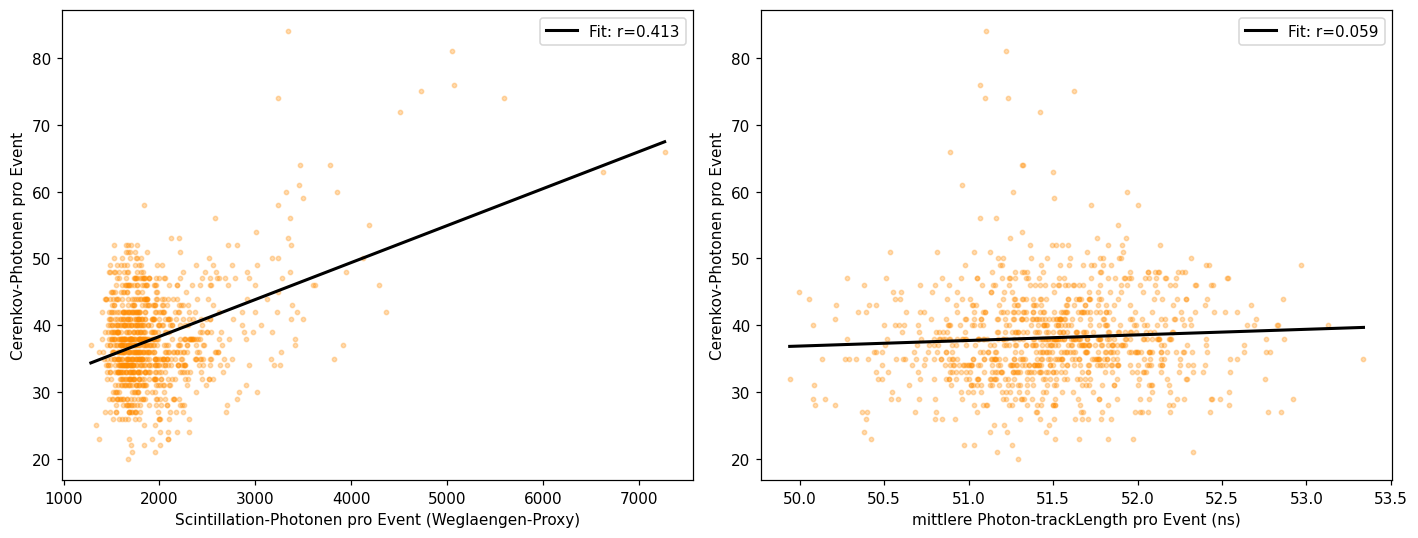

In [35]:
n_cerenkov = df.loc[df["creatorProcess"] == "Cerenkov"].groupby("eventID").size()
n_scintillation = df.loc[df["creatorProcess"] == "Scintillation"].groupby("eventID").size()
trackLength_mean = df.groupby("eventID")["trackLength"].mean()

event_stats = pd.DataFrame({
    "n_cerenkov": n_cerenkov,
    "n_scintillation": n_scintillation,
    "trackLength_mean": trackLength_mean,
}).fillna(0)

print(event_stats.describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, x_col, x_label in [(axes[0], "n_scintillation", "Scintillation-Photonen pro Event (Weglaengen-Proxy)"),
                            (axes[1], "trackLength_mean", "mittlere Photon-trackLength pro Event (ns)")]:
    x_vals = event_stats[x_col].to_numpy()
    y_vals = event_stats["n_cerenkov"].to_numpy()
    r = np.corrcoef(x_vals, y_vals)[0, 1]
    slope, intercept = np.polyfit(x_vals, y_vals, 1)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)

    ax.scatter(x_vals, y_vals, s=8, alpha=0.3, color="darkorange")
    ax.plot(x_line, slope * x_line + intercept, color="black", lw=2, label=f"Fit: r={r:.3f}")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Cerenkov-Photonen pro Event")
    ax.legend()

plt.tight_layout()
plt.show()

**Ergebnis:** Gegen die Scintillation-Photonenzahl (Weglaengen-Proxy) zeigt `n_cerenkov` eine deutliche positive Korrelation ($r=0{,}413$) - genau wie von Frank-Tamm ($dN_{cer}/dx\approx$ const.) und $dE/dx\approx$ const. fuer ein MIP-Elektron erwartet: beide Photonenzahlen wachsen gemeinsam mit der (event-zu-event leicht variierenden) Elektronen-Weglaenge. Gegen die mittlere Photon-`trackLength` zeigt sich dagegen praktisch keine Korrelation ($r=0{,}059$) - das bestaetigt, dass `trackLength` (optische Transportstrecke inkl. Reflexionen) unabhaengig von der Elektronenbahn ist und sich nicht als Weglaengen-Proxy eignet.